# Reanalysis Heiser et al.
To validate the findings from our MIBI study, we explore spatial pattern in the data generated by [Heiser et al. (2023)](https://www.sciencedirect.com/science/article/pii/S0092867423012229).  
Input data was obtained from [pre-processed spot-level data](https://osf.io/hftq2/) following the [notebook provided to summarize spatial transcriptomics data](https://github.com/Ken-Lau-Lab/spatial_CRC_atlas/blob/main/step5/ST_summaries.ipynb) (the object `a_comb` was exported).

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
from plotnine import *
import decoupler as dc
from matplotlib import pyplot as plt

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
# For signature CLR
from scipy.stats import gmean
from scipy.stats import spearmanr

In [3]:
# For classification
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import f1_score
from sklearn.model_selection import LeaveOneGroupOut
from tqdm import tqdm

In [4]:
# Load data
a_comb = sc.read_h5ad("../../data/Heiser_ST_combined.h5ad")
# Select cancer spots
cancer_spots = a_comb[a_comb.obs['Tumor Grade'].isin(['G1', 'G2', 'G3'])].copy()
print(cancer_spots.obs['Tumor Grade'].value_counts())

Tumor Grade
G2    65294
G3    27775
G1    19648
Name: count, dtype: int64


## Immune infiltration


=== Grade G1 (n=19648 spots) ===
Fibroblast vs Tumor: -0.243


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_fibroblast_tumor_grade_G1.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 22 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 7 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_fibroblast_tumor_grade_G1.png
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: Plotn

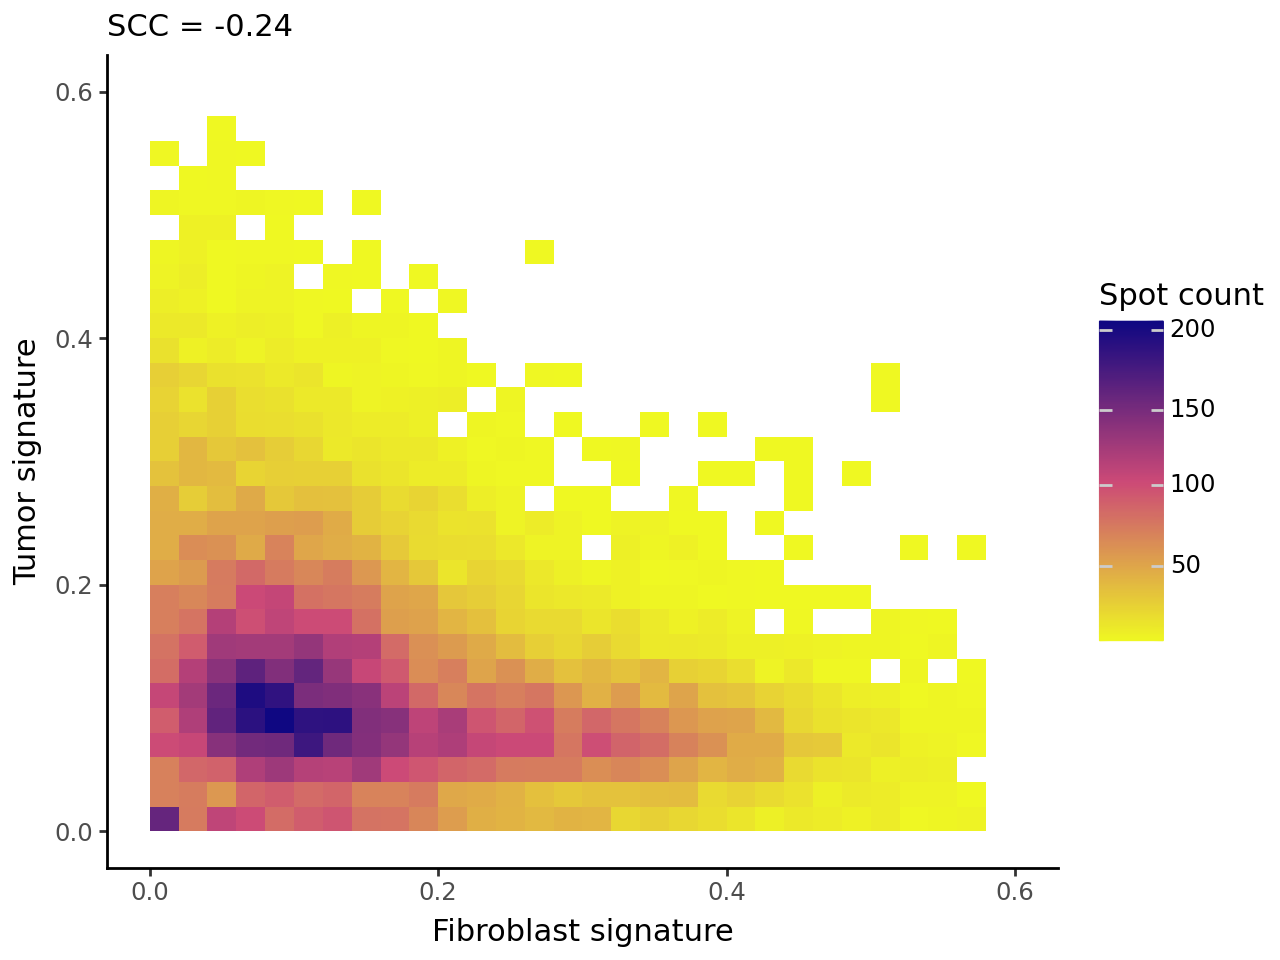

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_tumor_grade_G1.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 334 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 12 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_tumor_grade_G1.png
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWar

Immune vs Tumor: -0.242


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 12 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 334 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 12 rows containing missing values.


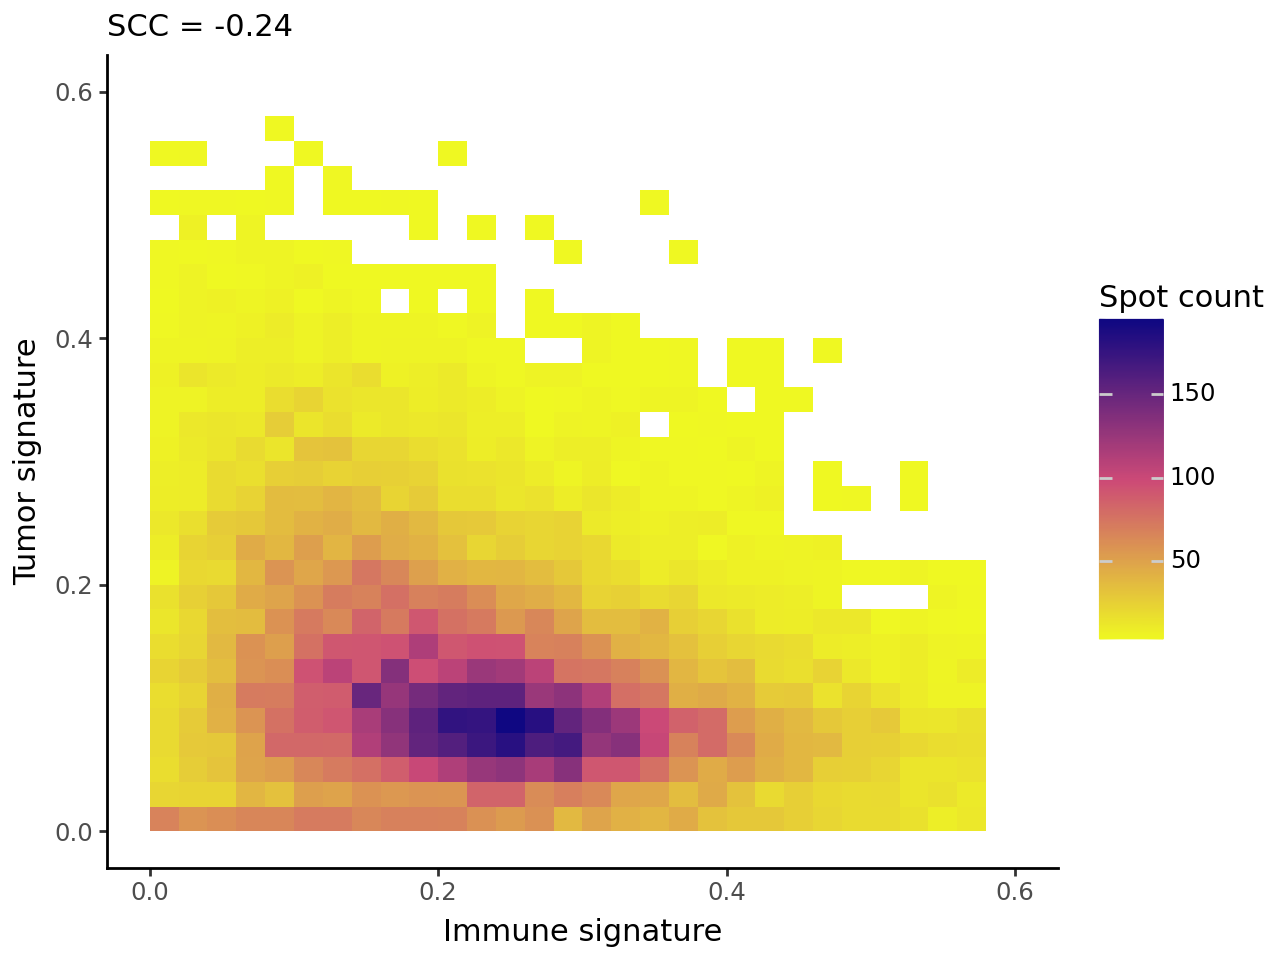

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_fibroblast_grade_G1.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 342 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 18 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_fibroblast_grade_G1.png
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: P

Immune vs Fibroblast: 0.133


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 342 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 18 rows containing missing values.


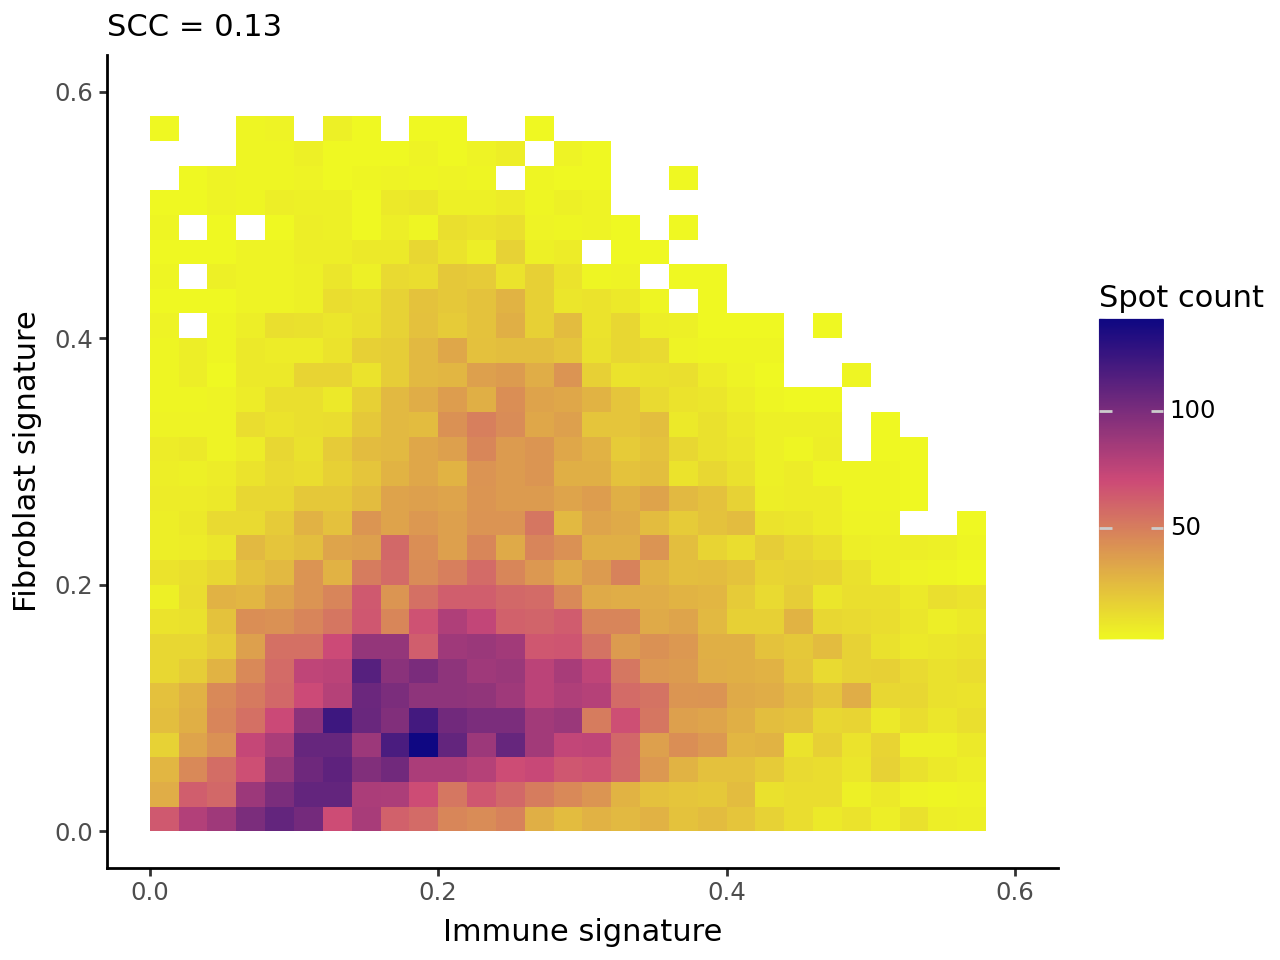

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_fibroblast_tumor_grade_G2.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 267 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 22 rows containing missing values.



=== Grade G2 (n=65294 spots) ===
Fibroblast vs Tumor: -0.462


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_fibroblast_tumor_grade_G2.png
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 267 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 22 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 267 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 22 rows containing missing values.


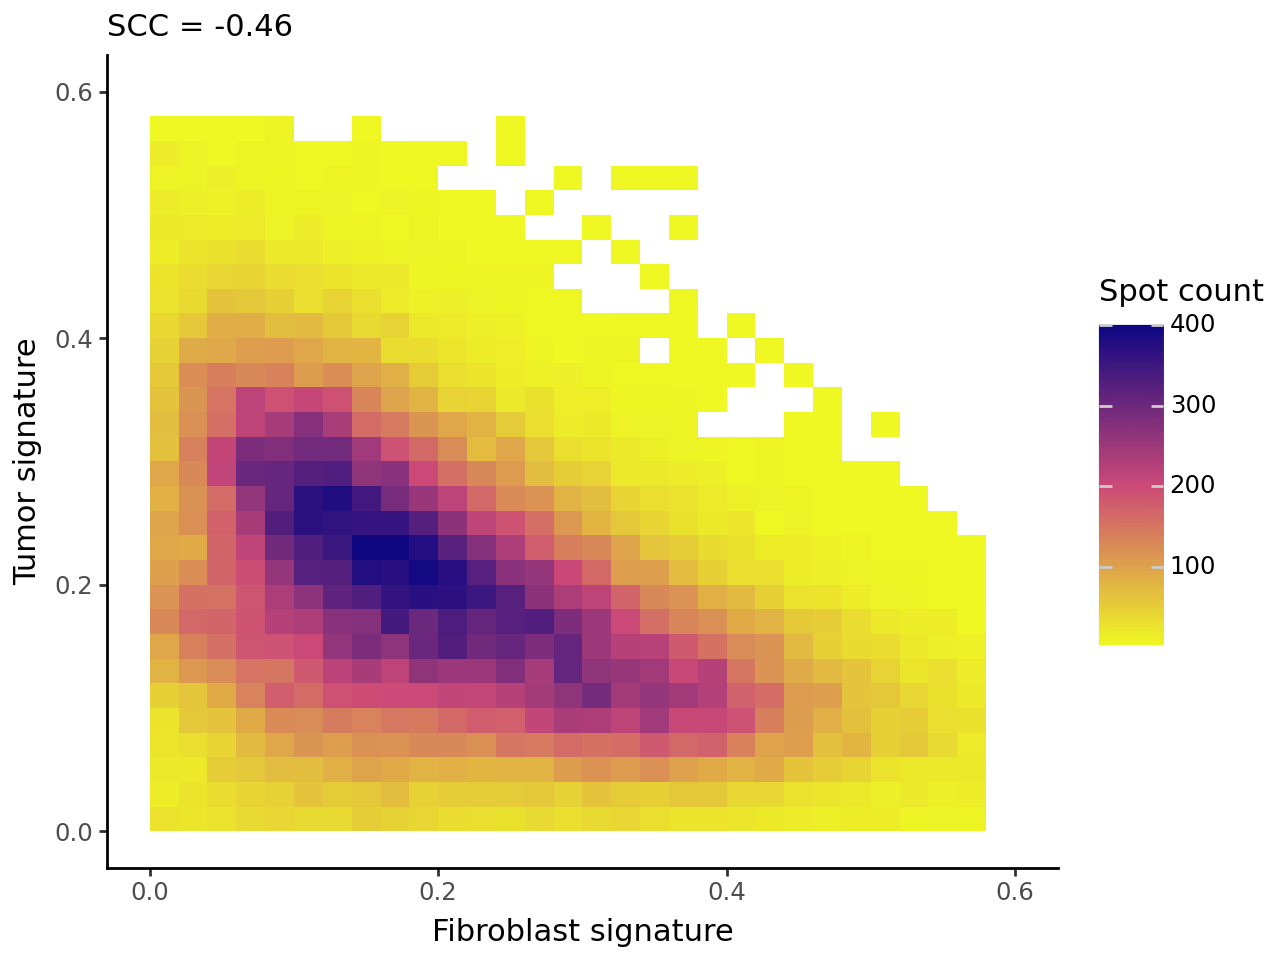

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_tumor_grade_G2.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 428 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 22 rows containing missing values.


Immune vs Tumor: -0.260


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_tumor_grade_G2.png
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 428 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 22 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 428 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 22 rows containing missing values.


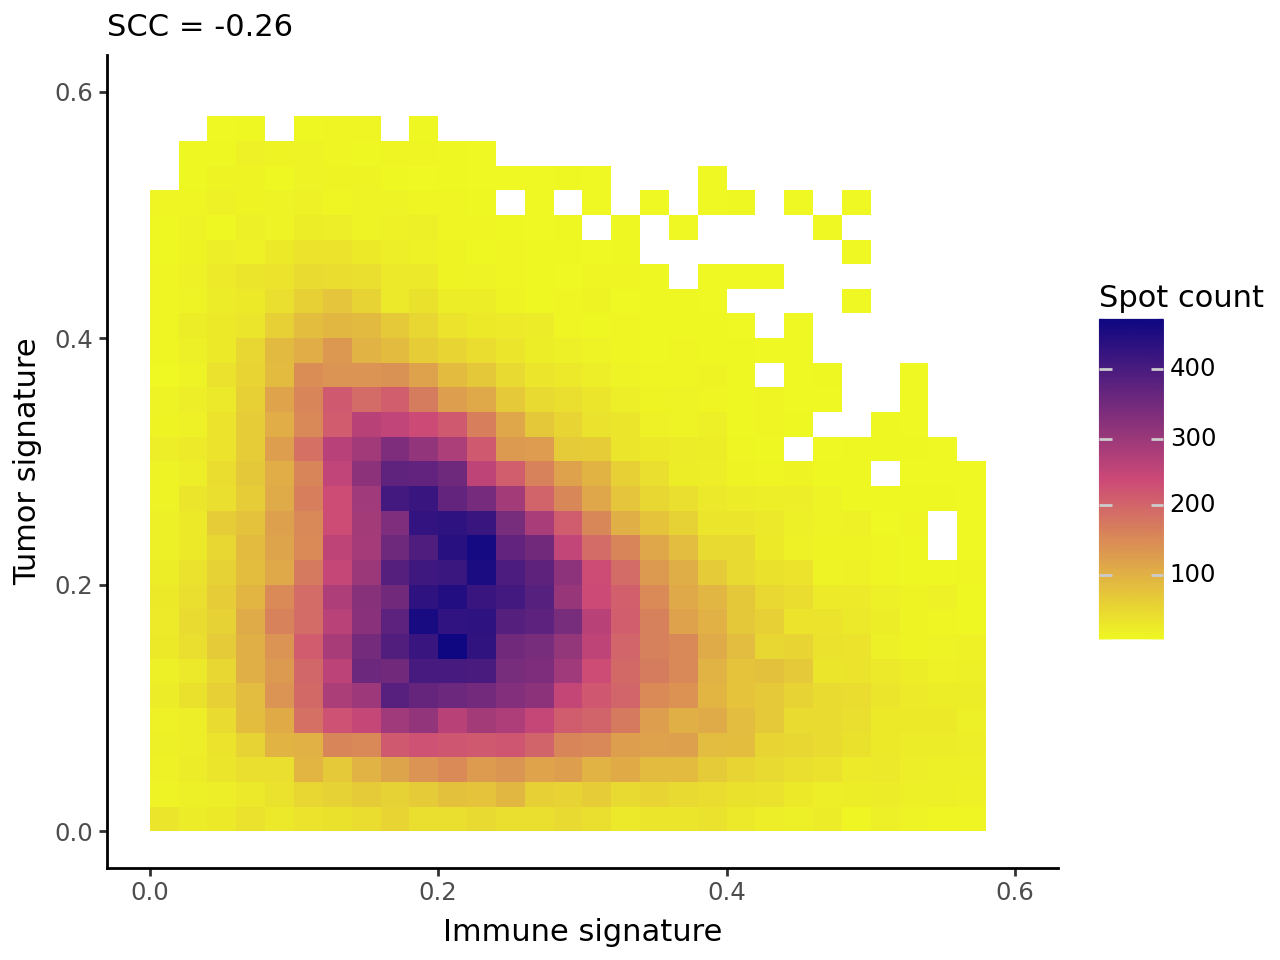

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_fibroblast_grade_G2.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 601 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 31 rows containing missing values.


Immune vs Fibroblast: 0.070


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_fibroblast_grade_G2.png
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 601 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 31 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 601 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 31 rows containing missing values.


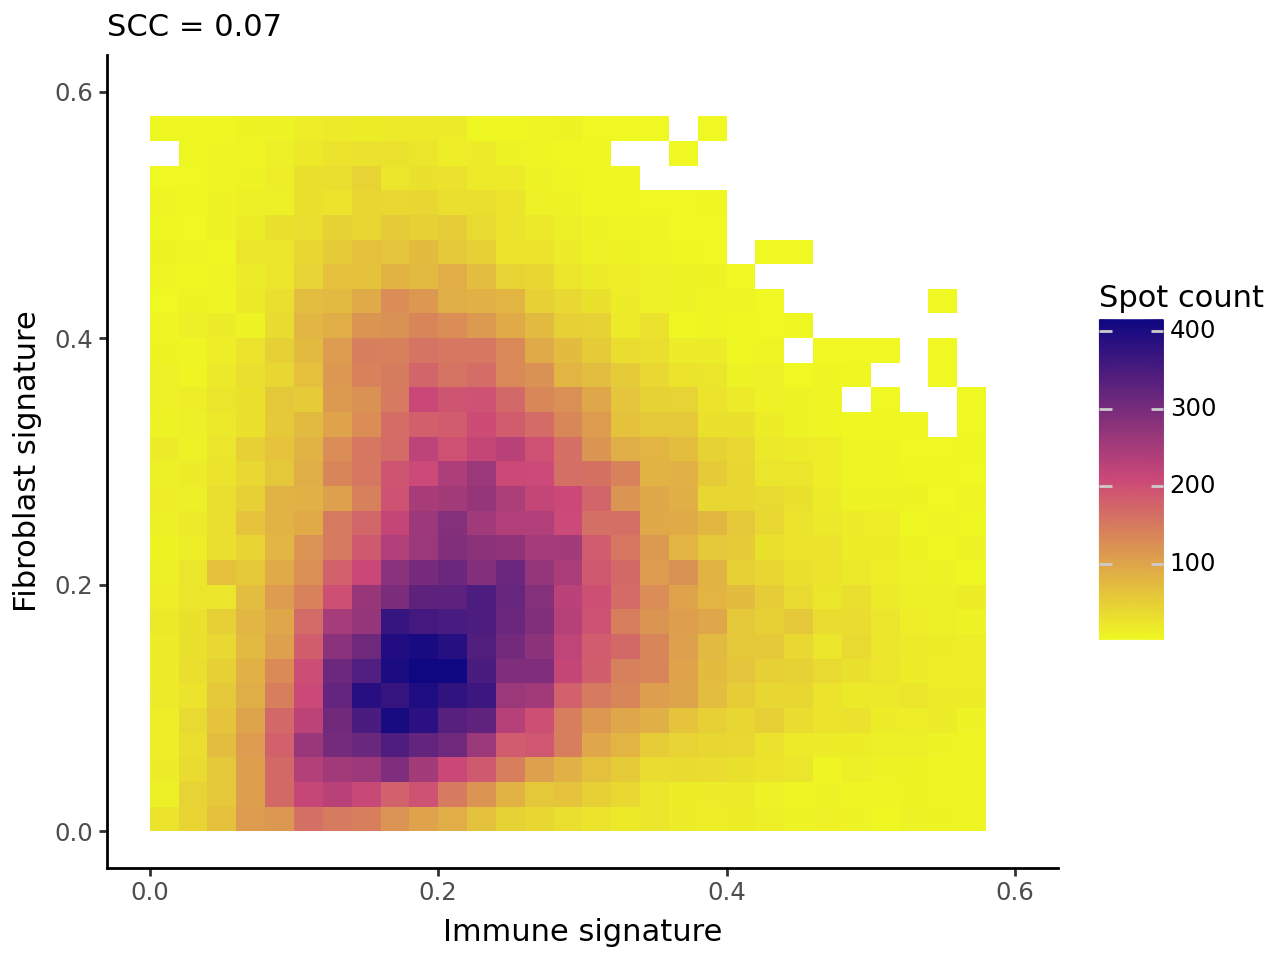


=== Grade G3 (n=27775 spots) ===
Fibroblast vs Tumor: -0.635


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_fibroblast_tumor_grade_G3.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 155 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 10 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_fibroblast_tumor_grade_G3.png
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: Plo

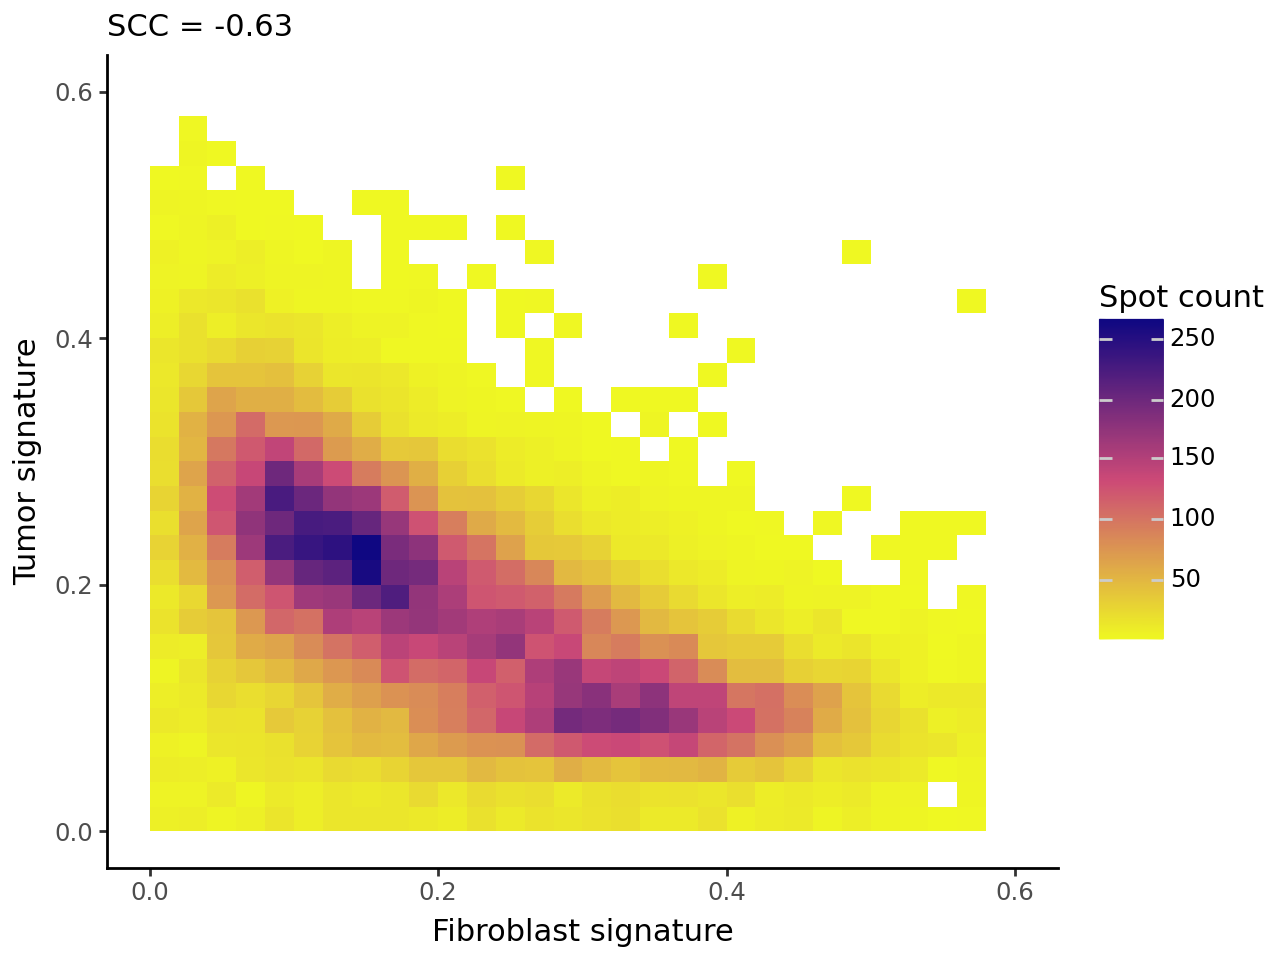

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_tumor_grade_G3.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 356 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 15 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_tumor_grade_G3.png


Immune vs Tumor: -0.280


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 356 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 15 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 356 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 15 rows containing missing values.


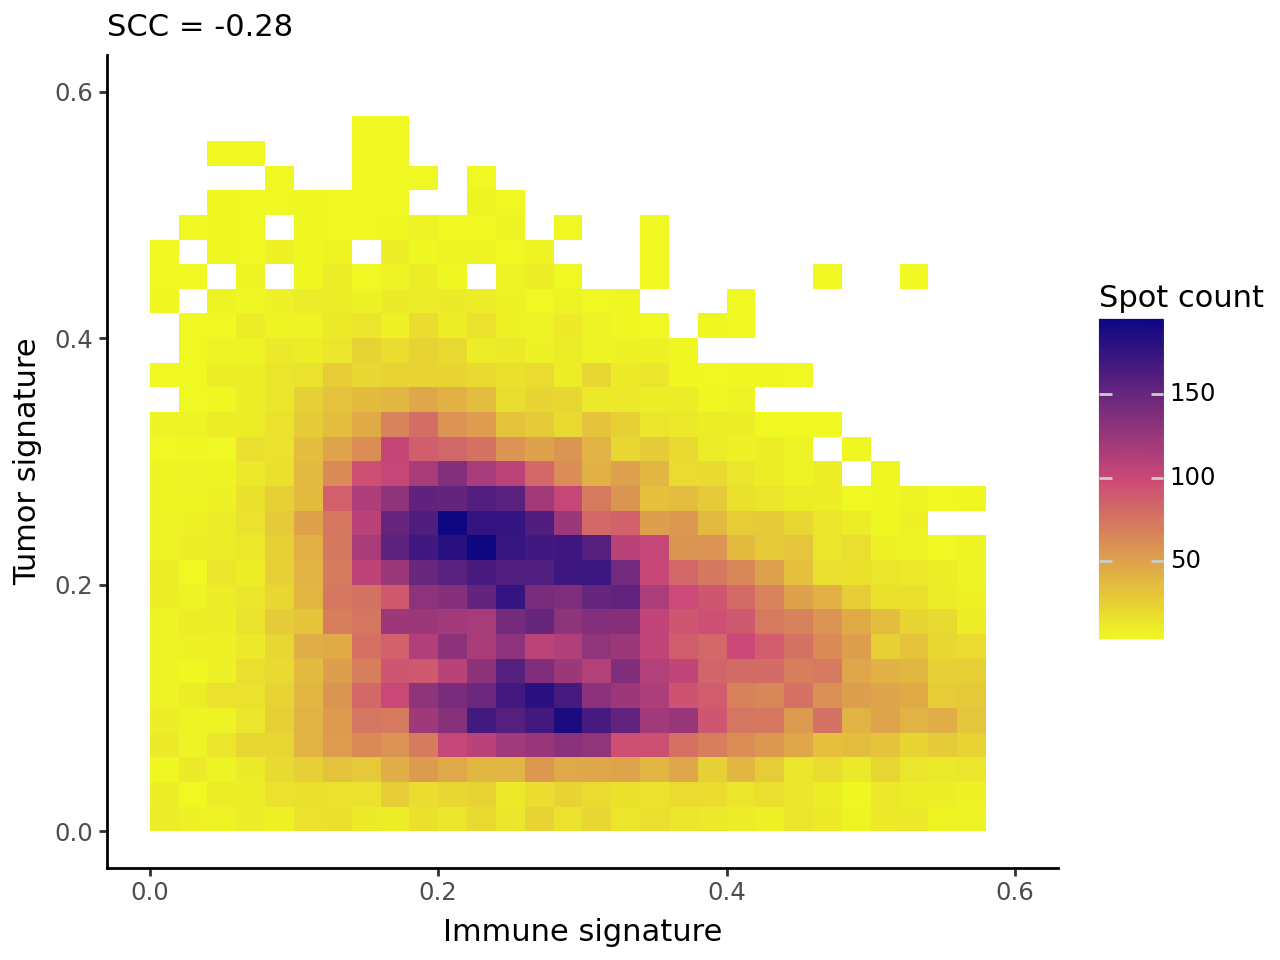

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_fibroblast_grade_G3.pdf
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 482 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 28 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_immune_fibroblast_grade_G3.png


Immune vs Fibroblast: -0.051


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 482 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 28 rows containing missing values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin_2d : Removed 482 rows containing non-finite values.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_bin_2d : Removed 28 rows containing missing values.


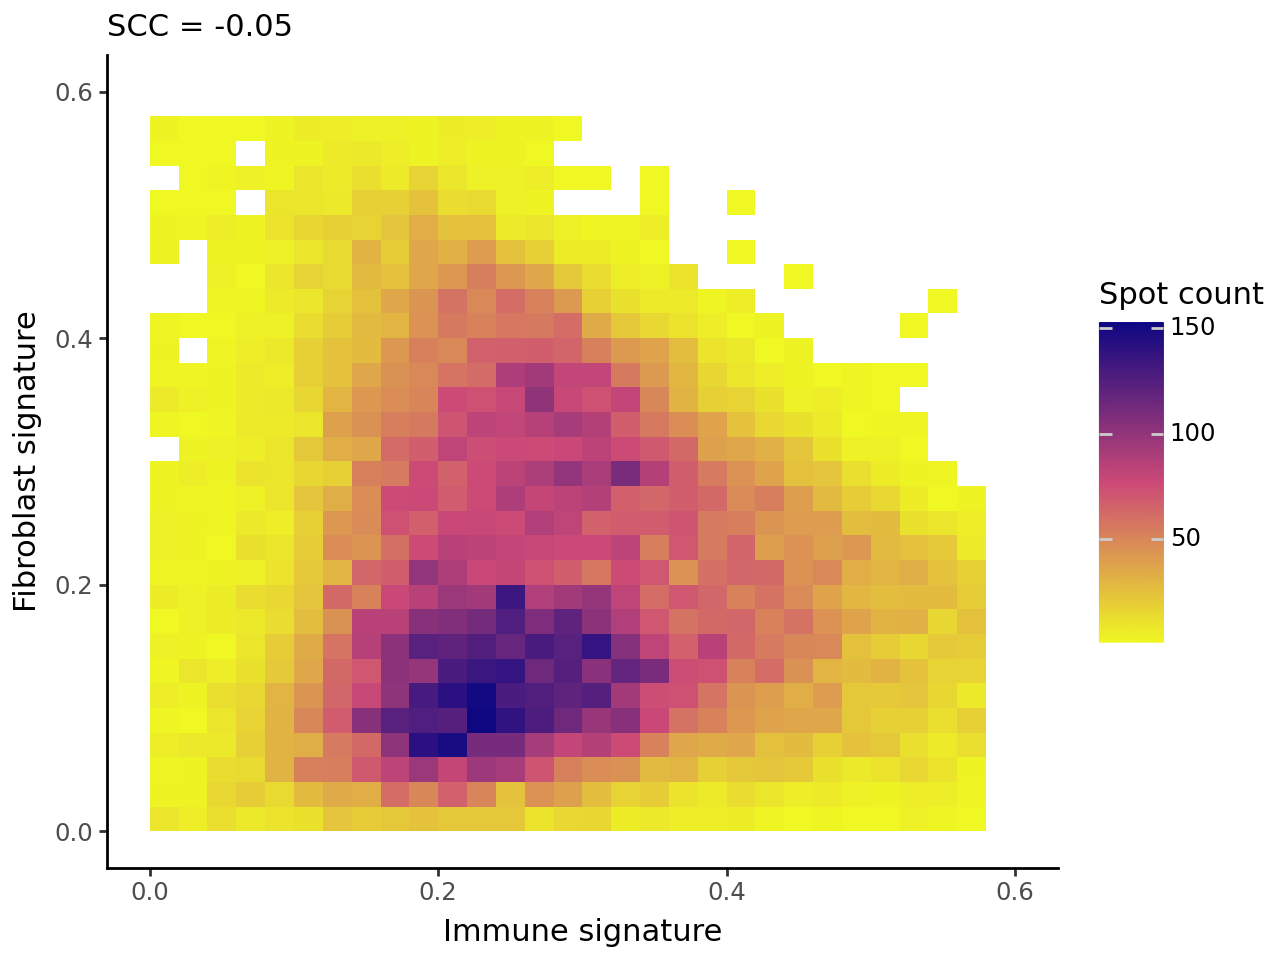

/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5.5 x 2 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_fibroblast_correlations_heatmap.pdf


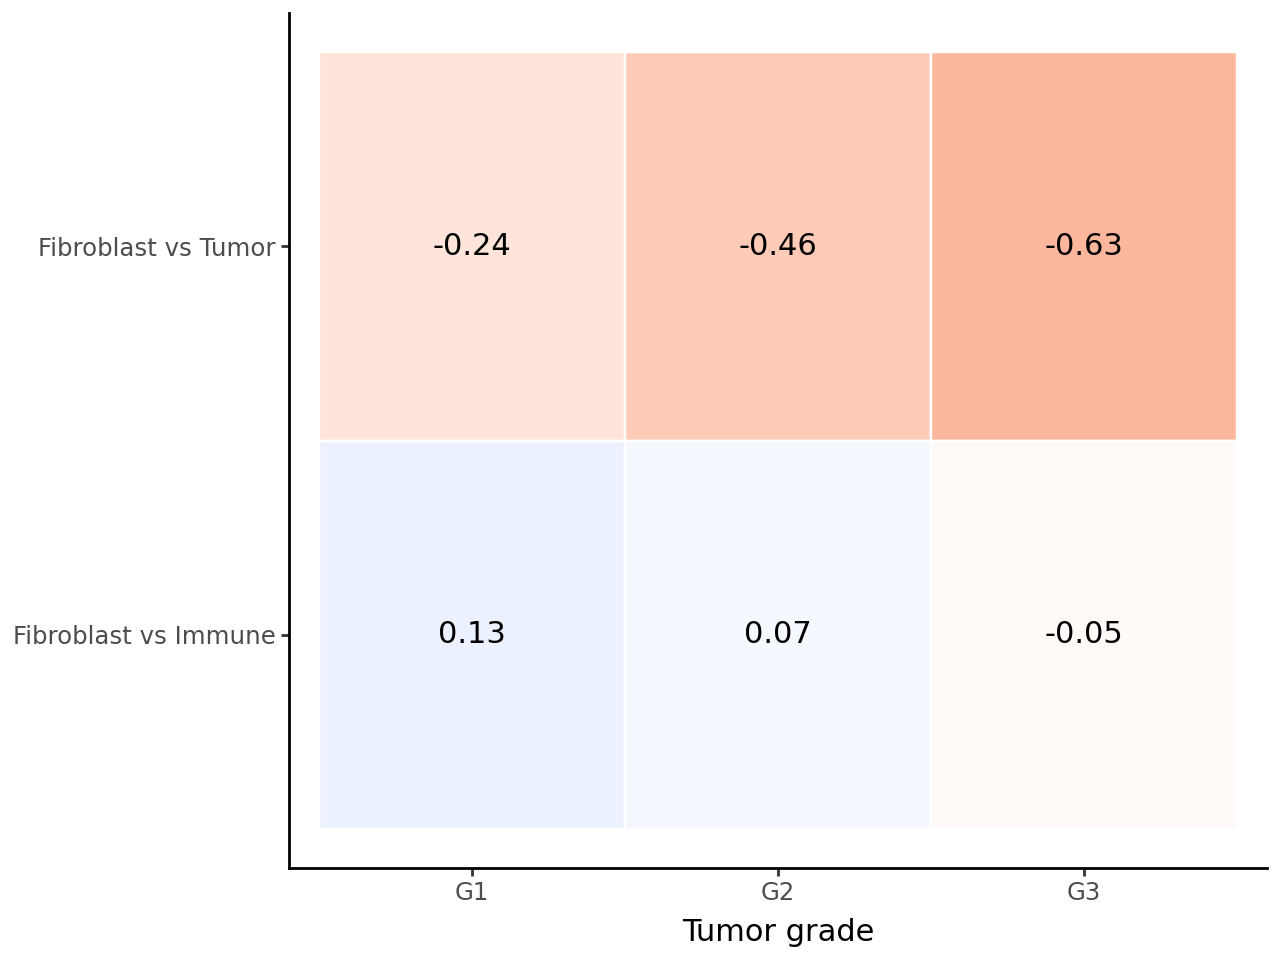


=== CORRELATION SUMMARY ===
Fibroblast vs Tumor correlations by grade:
  Grade G1: -0.243
  Grade G2: -0.462
  Grade G3: -0.635

Fibroblast vs Immune correlations by grade:
  Grade G1: 0.133
  Grade G2: 0.070
  Grade G3: -0.051


In [8]:
# Calculate signature totals for all cancer spots
cancer_spots.obs['CRC_tot'] = cancer_spots.obs['CRC1'] + cancer_spots.obs['CRC2'] + cancer_spots.obs['CRC3'] + cancer_spots.obs['CRC4']
cancer_spots.obs['FIB_tot'] = cancer_spots.obs['FIB1'] + cancer_spots.obs['FIB2'] + cancer_spots.obs['FIB3'] + cancer_spots.obs['FIB4']
cancer_spots.obs['IMMU_tot'] = cancer_spots.obs['MYE1'] + cancer_spots.obs['MYE2'] + cancer_spots.obs['MYE3'] + cancer_spots.obs['MYE4'] + \
    cancer_spots.obs['MYE5'] + cancer_spots.obs['TL1'] + cancer_spots.obs['TL2'] + cancer_spots.obs['TL3'] + cancer_spots.obs['BL1'] + cancer_spots.obs['BL2']

# Human-friendly labels
label_dict = {
    'CRC_tot': 'Tumor',
    'FIB_tot': 'Fibroblast', 
    'IMMU_tot': 'Immune'
}

# Store correlations for heatmap
correlation_results = []

# Analyze correlations for each tumor grade
for grade in cancer_spots.obs['Tumor Grade'].unique():
    grade_data = cancer_spots.obs[cancer_spots.obs['Tumor Grade'] == grade]
    
    print(f"\n=== Grade {grade} (n={len(grade_data)} spots) ===")
    
    # Calculate correlations between all pairs
    for x in label_dict.keys():
        for y in label_dict.keys():
            if x > y:  # Avoid duplicates
                correlation = grade_data[x].corr(grade_data[y], method='spearman')
                
                print(f"{label_dict[x]} vs {label_dict[y]}: {correlation:.3f}")
                
                # Store for heatmap
                correlation_results.append({
                    'Grade': grade,
                    'Signature_1': label_dict[x],
                    'Signature_2': label_dict[y], 
                    'Correlation': correlation
                })
                
                # Create individual scatter plot
                g = (
                    ggplot(grade_data, aes(x=x, y=y))
                    + geom_bin_2d()
                    + xlim(0, 0.6)
                    + ylim(0, 0.6)
                    + ggtitle(subtitle=f"SCC = {correlation:.2f}")
                    + theme_classic()
                    + scale_fill_gradientn(colors=["#EFF822", "#CC4977", "#0F0782"])
                    + labs(x=f"{label_dict[x]} signature",
                           y=f"{label_dict[y]} signature",
                           fill="Spot count")
                )
                
                # Save plots
                safe_x = label_dict[x].lower()
                safe_y = label_dict[y].lower()
                ggsave(g, filename=f"../../figures/fig6/heiser_{safe_x}_{safe_y}_grade_{grade}.pdf",
                       width=3, height=2)            
                ggsave(g, filename=f"../../figures/fig6/heiser_{safe_x}_{safe_y}_grade_{grade}.png",
                       width=3, height=2)
                g.show()

# Create correlation results DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Create heatmap data focusing on Fibroblast correlations
heatmap_data = []

# Add Fibroblast vs Tumor correlations
fib_tumor_correlations = correlation_df[
    ((correlation_df['Signature_1'] == 'Fibroblast') & (correlation_df['Signature_2'] == 'Tumor')) |
    ((correlation_df['Signature_1'] == 'Tumor') & (correlation_df['Signature_2'] == 'Fibroblast'))
]

for _, row in fib_tumor_correlations.iterrows():
    heatmap_data.append({
        'Comparison': 'Fibroblast vs Tumor',
        'Grade': row['Grade'],
        'Correlation': row['Correlation']
    })

# Add Fibroblast vs Immune correlations  
fib_immune_correlations = correlation_df[
    ((correlation_df['Signature_1'] == 'Fibroblast') & (correlation_df['Signature_2'] == 'Immune')) |
    ((correlation_df['Signature_1'] == 'Immune') & (correlation_df['Signature_2'] == 'Fibroblast'))
]

for _, row in fib_immune_correlations.iterrows():
    heatmap_data.append({
        'Comparison': 'Fibroblast vs Immune', 
        'Grade': row['Grade'],
        'Correlation': row['Correlation']
    })

# Convert to DataFrame
heatmap_df = pd.DataFrame(heatmap_data)

# Create heatmap
g_heatmap = (
    ggplot(heatmap_df, aes(x='Grade', y='Comparison', fill='Correlation')) +
    geom_tile(color='white', size=0.5) +
    geom_text(aes(label=heatmap_df['Correlation'].round(2)), 
              color='black') +
    scale_fill_gradient2(low='#FC8D62', mid='white', high='#6291FC', # #73412D / FC8D62 / 8DA0CB / #6291FC / #505B73
                         midpoint=0, limits=[-1,1]) +
    labs(x='Tumor grade', 
         y='') +
    theme_classic() +
    guides(fill="none")
)

# Save heatmap
ggsave(g_heatmap, filename="../../figures/fig6/heiser_fibroblast_correlations_heatmap.pdf",
       width=5.5, height=2)

g_heatmap.show()

# Print summary
print("\n=== CORRELATION SUMMARY ===")
print("Fibroblast vs Tumor correlations by grade:")
for _, row in fib_tumor_correlations.iterrows():
    print(f"  Grade {row['Grade']}: {row['Correlation']:.3f}")

print("\nFibroblast vs Immune correlations by grade:")
for _, row in fib_immune_correlations.iterrows():
    print(f"  Grade {row['Grade']}: {row['Correlation']:.3f}")

### Illustrate

In [ ]:
cancer_spots[cancer_spots.obs['Sample'] == '8899_3'].obs.head(1)

In [ ]:
# Convert to long format
vars_to_expand = ["CRC_tot", "FIB_tot", "IMMU_tot"]
a_samp = cancer_spots[cancer_spots.obs['Sample'] == '8899_3']
# Convert to z-score
a_samp.obs[vars_to_expand] = a_samp.obs[vars_to_expand].apply(lambda x: (x - x.mean()) / x.std(), axis=0)
# Discretize
a_samp.obs[vars_to_expand] = a_samp.obs[vars_to_expand].apply(lambda x: pd.qcut(x, q=3, labels=False), axis=0)
# Convert to long format
a_samp = a_samp.obs.melt(
    id_vars=['array_row', 'array_col', 'Sample'], 
    value_vars=vars_to_expand, 
    var_name='Cell_Type', 
    value_name='Signature')
gp = ggplot(a_samp, aes(x='array_row', y='array_col', color = 'Signature')) + \
    geom_point() +\
    facet_wrap('~Cell_Type', ncol=3) +\
    scale_colour_continuous('viridis_r') +\
    theme_classic() +\
    annotate("rect",
           xmin = 21, xmax = 31,
           ymin = 30, ymax = 52,
           color = "red", alpha = 0, linetype = "dashed") +\
    theme(legend_position="bottom")

ggsave(gp, filename=f"../../figures/fig6/heiser_example_shielding.pdf",
        width=6, height=5, dpi=300)
ggsave(gp, filename=f"../../figures/fig6/heiser_example_shielding.png",
        width=6, height=5, dpi=300)
gp.show()

## Hypoxia

In [ ]:
print(f"Number of patients: {cancer_spots.obs['Patient'].nunique()}")
print(f"Number of samples: {cancer_spots.obs.groupby(['Sample', 'Patient', 'Tumor Grade']).ngroups}")

In [ ]:
# Check CA9 vs GLUT1 (SLC2A1)
hypoxia_df = pd.DataFrame({
    'SLC2A1': cancer_spots.X[:,cancer_spots.var_names == "SLC2A1"][:,0],
    'CA9': cancer_spots.X[:,cancer_spots.var_names == "CA9"][:,0],
    'Grade': cancer_spots.obs["Tumor Grade"],
    'Sample': cancer_spots.obs["Sample"],
    'Patient': cancer_spots.obs["Patient"]
})

# Compute CA9-GLUT1 correlation per sample
hypoxia_corr = pd.DataFrame(
    hypoxia_df.groupby(['Sample', 'Patient', 'Grade']).apply(
        lambda x: x['SLC2A1'].corr(x['CA9'], method='spearman')))
hypoxia_corr.columns = ['SCC']
hypoxia_corr = hypoxia_corr.reset_index()

gp = (ggplot(hypoxia_corr, aes(x='Grade', y='SCC', fill='Grade')) 
      + geom_violin(style="right", scale="width", width = 1.25) 
      + stat_summary(fun_y=np.median, geom='point', color='white', size=2)
      + theme_classic() 
      + coord_flip()
      + scale_fill_brewer(palette = "Purples")
      + theme(legend_position = "none")
      + labs(y = "SCC across spots")
)

ggsave(gp, f"../../figures/fig6/heiser_CA9_GLUT1_correlation.pdf", width = 5.5, height = 2)
gp.show()

### Enrichment in all spots

In [ ]:
# Prepare progeny resource
progeny_net = dc.op.progeny(organism='human')

# Run progeny analysis
progeny_acts, progeny_padj = dc.mt.ulm(data=pd.DataFrame(
                                                cancer_spots.X,
                                                index=cancer_spots.obs_names,
                                                columns=cancer_spots.var_names), 
                                        net=progeny_net)

progeny_acts.head()

Note: normalizing per read count is unnecessary here (identical results) so the resulting enrichments values are not confounded.

In [ ]:
# Aggregate progeny activity results by Tumor Grade
progeny_acts['Tumor Grade'] = cancer_spots.obs['Tumor Grade']
aggregated_results = progeny_acts.groupby('Tumor Grade').median()

# Convert aggregated results to a long format for plotting
heatmap_data = aggregated_results.reset_index().melt(id_vars='Tumor Grade', var_name='Pathway', value_name='Activity')

# Create heatmap
g = (
    ggplot(heatmap_data, aes(x='Pathway', y='Tumor Grade', fill='Activity')) +
    geom_tile() +
    scale_fill_gradient2(low='#1f77b4', mid='lightgray', high='#c20019', midpoint=0) +
    labs(x="Pathway", y="Tumor grade", fill="Activity") +
    theme_classic() +
    theme(axis_text_x=element_text(rotation=90, hjust=1))
)

ggsave(g, filename="../../figures/fig6/heiser_all_spots_progeny_heatmap.pdf",
       width=6, height=5, dpi=300)
ggsave(g + theme(legend_position="bottom"), 
       filename="../../figures/fig6/heiser_all_spots_progeny_heatmap.png",
       width=6, height=5, dpi=300)
g.show()

## Factors

### Factor independence

In [ ]:
hallmark = dc.op.hallmark(organism="human")
hallmark = hallmark.loc[hallmark.source.isin(["GLYCOLYSIS",
                                              "FATTY_ACID_METABOLISM",
                                              "OXIDATIVE_PHOSPHORYLATION"]),:]

# Run msigdb analysis
msig_acts, msig_padj = dc.mt.ulm(data=pd.DataFrame(
                                                cancer_spots.X,
                                                index=cancer_spots.obs_names,
                                                columns=cancer_spots.var_names), 
                                        net=hallmark)

msig_acts.head()

In [ ]:
def clr_transform(data):
    """Apply centered log-ratio transformation to compositional data"""
    # Add small constant to avoid log(0)
    data_adj = data + 1e-6
    
    # Compute geometric mean for each row
    geometric_means = gmean(data_adj, axis=1)
    
    # Apply CLR transformation: log(x_i / geometric_mean)
    clr_data = np.log(data_adj.div(geometric_means, axis=0))
    
    return clr_data

In [ ]:
# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def normalize_simplex(df, cols):
    X = df[cols].to_numpy(dtype=float)
    # handle negatives or all-zeros robustly
    X = np.where(X < 0, 0, X)
    rowsum = X.sum(axis=1, keepdims=True)
    # if a row sums to 0, set equal parts
    X[rowsum.squeeze() == 0] = 1.0
    rowsum = X.sum(axis=1, keepdims=True)
    X = X / rowsum
    out = df.copy()
    out[cols] = X
    return out

def ternary_to_xy(df, cols):
    """
    Map composition (G, F, O) to Cartesian coordinates for an equilateral triangle.
    Vertices:
      G at (0, 0)
      F at (1, 0)
      O at (0.5, sqrt(3)/2)
    For row with fractions g, f, o:
      x = f + 0.5*o
      y = (sqrt(3)/2)*o
    """
    g, f, o = [df[c].to_numpy(dtype=float) for c in cols]
    x = f + 0.5 * o
    y = (np.sqrt(3) / 2.0) * o
    out = df.copy()
    out['_x'] = x
    out['_y'] = y
    return out

def triangle_frame():
    """Edges of the triangle as a DataFrame for geom_segment calls."""
    V = {
        'G': (0.0, 0.0),
        'F': (1.0, 0.0),
        'O': (0.5, np.sqrt(3)/2.0),
    }
    edges = pd.DataFrame([
        {'x': V['G'][0], 'y': V['G'][1], 'xend': V['F'][0], 'yend': V['F'][1]},
        {'x': V['F'][0], 'y': V['F'][1], 'xend': V['O'][0], 'yend': V['O'][1]},
        {'x': V['O'][0], 'y': V['O'][1], 'xend': V['G'][0], 'yend': V['G'][1]},
    ])
    labels = pd.DataFrame([
        {'x': V['G'][0]-0.04, 'y': V['G'][1]-0.04, 'lab': 'Glycolysis'},
        {'x': V['F'][0]+0.04, 'y': V['F'][1]-0.04, 'lab': 'FAO'},
        {'x': V['O'][0],      'y': V['O'][1]+0.06, 'lab': 'OxPhos'},
    ])
    return edges, labels

def grid_lines(levels=(0.2, 0.4, 0.6, 0.8)):
    """
    Return grid lines for isopleths of constant fraction for each component.
    Each line is given as a segment inside the triangle.
    """
    segs = []

    # Vertices
    G = np.array([0.0, 0.0])
    F = np.array([1.0, 0.0])
    O = np.array([0.5, np.sqrt(3)/2.0])

    def mix(p, q, t):
        return (1-t)*p + t*q

    # Lines of constant OxPhos = o
    for o in levels:
        # endpoints on GF edge where o=0
        a = mix(G, F, 0.0)  # G
        b = mix(G, F, 1.0)  # F
        # points along GO and FO edges where OxPhos fraction equals o
        p1 = mix(G, O, o)
        p2 = mix(F, O, o)
        segs.append({'x': p1[0], 'y': p1[1], 'xend': p2[0], 'yend': p2[1]})

    # Lines of constant FAO = f
    for f in levels:
        p1 = mix(G, F, f)
        p2 = mix(O, F, f)
        segs.append({'x': p1[0], 'y': p1[1], 'xend': p2[0], 'yend': p2[1]})

    # Lines of constant Glycolysis = g
    for g in levels:
        p1 = mix(G, O, g)
        p2 = mix(G, F, g)
        segs.append({'x': p1[0], 'y': p1[1], 'xend': p2[0], 'yend': p2[1]})

    return pd.DataFrame(segs)

# ---------------------------------------------------------------------
# Main plotting function
# ---------------------------------------------------------------------

def ternary_plot(
    df,
    cols=('GLYCOLYSIS', 'FATTY_ACID_METABOLISM', 'OXIDATIVE_PHOSPHORYLATION'),
    color=None,
    size=2.0,
    add_grid=True,
    grid_levels=(0.2, 0.4, 0.6, 0.8),
    palette='Dark2'
):
    cols = list(cols)
    assert len(cols) == 3, "Provide exactly three columns"

    # Normalize and project
    df_n = normalize_simplex(df, cols)
    df_xy = ternary_to_xy(df_n, cols)

    edges, labels = triangle_frame()
    p = (
        ggplot(df_xy)
        + coord_equal()
        + theme_void()
        + theme(plot_background=element_rect(fill='white', color='black'))
        + geom_segment(
            data=edges,
            mapping=aes(x='x', y='y', xend='xend', yend='yend'),
            size=1.0
        )
    )

    if add_grid:
        grid = grid_lines(levels=grid_levels)
        p = p + geom_segment(
            data=grid,
            mapping=aes(x='x', y='y', xend='xend', yend='yend'),
            alpha=0.25,
            size=0.3
        )

    # Labels at vertices
    p = p + geom_text(
        data=labels,
        mapping=aes(x='x', y='y', label='lab'),
        size=10
    )

    # Points
    aes_kwargs = {'x': '_x', 'y': '_y'}
    if color is not None:
        aes_kwargs['color'] = color

    p = p + geom_point(aes(x='_x', y='_y'), size=size+1.5, color="black") +\
        geom_point(aes(**aes_kwargs), size=size)

    if color is not None:
        p = p + scale_color_brewer(type='qual', palette=palette) + guides(color=guide_legend(title=color))

    return p


In [ ]:
# ---------------------------
# Utilities
# ---------------------------

def close_rows(X):
    """Ensure nonnegative, handle all-zero rows, and close to the simplex."""
    X = np.asarray(X, dtype=float)
    X = np.maximum(X, 0.0)
    s = X.sum(axis=1, keepdims=True)
    zero = (s.squeeze() == 0)
    if np.any(zero):
        X[zero] = 1.0
        s = X.sum(axis=1, keepdims=True)
    return X / s

def edge_proximity(X):
    """
    Mean edge proximity:
      E = 1 - 3 * mean(min_i(row_i))
    Larger E => compositions closer to edges/corners.
    """
    X = close_rows(X)
    return 1.0 - 3.0 * np.mean(np.min(X, axis=1))

# ---------------------------
# Dirichlet(1,1,1) Monte Carlo test
# ---------------------------

def dirichlet_edge_test(X, B=10000, seed=0, tail="greater"):
    """
    Test mean edge proximity against a uniform Dirichlet(1,1,1) null.
    tail="greater" tests for edge bias (observed > null).
    Returns: observed_stat, null_stats, p_value
    """
    rng = np.random.default_rng(seed)
    X = close_rows(X)
    n = X.shape[0]

    t_obs = edge_proximity(X)

    # Simulate B replicates, each of size n
    sims = rng.dirichlet([1.0, 1.0, 1.0], size=(B, n))
    # sims has shape (B, n, 3); compute stat per replicate
    t_null = 1.0 - 3.0 * np.min(sims, axis=2).mean(axis=1)

    if tail == "greater":
        p = (np.sum(t_null >= t_obs) + 1) / (B + 1)
    elif tail == "less":
        p = (np.sum(t_null <= t_obs) + 1) / (B + 1)
    else:  # two-sided
        p = (np.sum(np.abs(t_null - t_null.mean()) >= np.abs(t_obs - t_null.mean())) + 1) / (B + 1)

    return t_obs, t_null, p

In [ ]:
# ------------------------------------------------------------
# Helpers: closure and ternary projection (G, F, O) -> (x, y)
# ------------------------------------------------------------
def project_xy(G, F, O):
    # Vertices: G=(0,0), F=(1,0), O=(0.5, sqrt(3)/2)
    x = F + 0.5 * O
    y = (np.sqrt(3) / 2.0) * O
    return x, y

# ------------------------------------------------------------
# Statistic functions
# ------------------------------------------------------------
def stat_mean_fao(df, g_col, f_col, o_col, grade_col, target_grade):
    # Ensure compositions are closed
    X = close_rows(df[[g_col, f_col, o_col]].to_numpy())
    f = X[:, 1]  # FAO after closure
    mask = df[grade_col].to_numpy() == target_grade
    return float(f[mask].mean())

def stat_mean_xy_dist(df, g_col, f_col, o_col, grade_col, target_grade):
    X = close_rows(df[[g_col, f_col, o_col]].to_numpy())
    g, f, o = X.T
    x, y = project_xy(g, f, o)
    # Distance to FAO vertex at (1, 0)
    d = np.sqrt((x - 1.0)**2 + y**2)
    mask = df[grade_col].to_numpy() == target_grade
    return float(d[mask].mean())

# ------------------------------------------------------------
# Permutation test on labels
# ------------------------------------------------------------
def perm_test_fao_vertex(
    df,
    g_col='GLYCOLYSIS',
    f_col='FATTY_ACID_METABOLISM',
    o_col='OXIDATIVE_PHOSPHORYLATION',
    grade_col='Tumor_Grade',
    target_grade='G1',
    B=10000,
    seed=0,
    which_stat='mean_xy_dist'
):
    """
    Null: Tumor_Grade labels are exchangeable across samples.
    Alternative for mean_xy_dist: G1 is closer to FAO vertex than random (smaller mean distance).
    Alternative for mean_fao:     G1 has higher FAO fraction than random (larger mean FAO).
    """
    rng = np.random.default_rng(seed)

    if which_stat == 'mean_xy_dist':
        stat_fn = stat_mean_xy_dist
        tail = 'less'     # smaller distances indicate closer to FAO vertex
    elif which_stat == 'mean_fao':
        stat_fn = stat_mean_fao
        tail = 'greater'  # larger FAO indicates closer to FAO vertex
    else:
        raise ValueError("which_stat must be 'mean_xy_dist' or 'mean_fao'")

    t_obs = stat_fn(df, g_col, f_col, o_col, grade_col, target_grade)

    grades = df[grade_col].to_numpy()
    t_null = np.empty(B, dtype=float)
    for b in range(B):
        perm = rng.permutation(len(grades))
        df_perm = df.copy()
        df_perm[grade_col] = grades[perm]
        t_null[b] = stat_fn(df_perm, g_col, f_col, o_col, grade_col, target_grade)

    if tail == 'less':
        p = (np.sum(t_null <= t_obs) + 1) / (B + 1)
    else:  # 'greater'
        p = (np.sum(t_null >= t_obs) + 1) / (B + 1)

    return t_obs, t_null, p

Example on how to use the ternary diagram methods and the permutation tests:
```Python
# Example DataFrame
rng = np.random.default_rng(42)
X = rng.dirichlet([0.2, 0.2, 0.2], size=200)  # columns in order [G, F, O]
df = pd.DataFrame(X, columns=['GLYCOLYSIS', 'FATTY_ACID_METABOLISM', 'OXIDATIVE_PHOSPHORYLATION'])
df['Tumor_Grade'] = rng.choice(['G1', 'G2', 'G3'], size=len(df), p=[0.3, 0.4, 0.3])

p = ternary_plot(
    df,
    cols=('GLYCOLYSIS', 'FATTY_ACID_METABOLISM', 'OXIDATIVE_PHOSPHORYLATION'),
    color='Tumor_Grade',
    size=2.2,
    add_grid=True
)

# Dirichlet(1,1,1) null
t_obs, t_dir, p_dir = dirichlet_edge_test(df[['GLYCOLYSIS', 
                                              'FATTY_ACID_METABOLISM', 
                                              'OXIDATIVE_PHOSPHORYLATION']].values, 
                                          B=10000, 
                                          seed=1, 
                                          tail="two-sided")
print(f"Observed edge proximity: {t_obs:.4f}")
print(f"Dirichlet(1,1,1) test p-value (edge-biased): {p_dir:.4f}")

# Test with mean distance in ternary XY space
t_obs_d, t_null_d, p_d = perm_test_fao_vertex(
    df,
    grade_col='Tumor_Grade',
    target_grade='G1',
    B=5000,
    seed=1,
    which_stat='mean_xy_dist'
)
print(f"Observed mean XY distance to FAO vertex (G1): {t_obs_d:.4f}")
print(f"Permutation p-value (closer than random): {p_d:.4f}")

# Test with mean FAO fraction
t_obs_f, t_null_f, p_f = perm_test_fao_vertex(
    df,
    grade_col='Tumor_Grade',
    target_grade='G1',
    B=5000,
    seed=1,
    which_stat='mean_fao'
)
print(f"Observed mean FAO fraction (G1): {t_obs_f:.4f}")
print(f"Permutation p-value (higher than random): {p_f:.4f}")

p.show()
```

In [17]:
# 1) Compute two new columns in cancer_spots.obs
print("Computing epithelial and myeloid signature totals...")

# Epithelial signatures (from the multicellularity section)
epi_ft = [
    'STM', 'CRC1', 'CRC2', 'CT', 'SSC', 'CRC3', 'EE1', 'GOB', 'CRC4', 'ABS', 'TUF', 'EE2'
]

# Myeloid signatures
mye_ft = ['MYE1', 'MYE2', 'MYE3', 'MYE4', 'MYE5']

# Compute totals
cancer_spots.obs['Epi_tot'] = cancer_spots.obs[epi_ft].sum(axis=1)
cancer_spots.obs['Mye_tot'] = cancer_spots.obs[mye_ft].sum(axis=1)

print(f"Epi_tot range: {cancer_spots.obs['Epi_tot'].min():.3f} - {cancer_spots.obs['Epi_tot'].max():.3f}")
print(f"Mye_tot range: {cancer_spots.obs['Mye_tot'].min():.3f} - {cancer_spots.obs['Mye_tot'].max():.3f}")

# 2) Aggregate msig_acts per group and normalize
print("Aggregating and normalizing msig_acts per group...")

# Add grouping variables to msig_acts
msig_acts_with_groups = msig_acts.copy()
msig_acts_with_groups['Sample'] = cancer_spots.obs['Sample']
msig_acts_with_groups['Patient'] = cancer_spots.obs['Patient']
msig_acts_with_groups['Tumor_Grade'] = cancer_spots.obs['Tumor Grade']

# Define metabolic pathway columns
msig_cols = ['FATTY_ACID_METABOLISM', 'GLYCOLYSIS', 'OXIDATIVE_PHOSPHORYLATION']

# Aggregate by taking median per group
msig_aggregated = msig_acts_with_groups.groupby(['Sample', 'Patient', 'Tumor_Grade'], 
                                                observed=True).median().reset_index()

# # Scale each column to be in [0,1]
for col in msig_cols:
    msig_aggregated[col] = ((msig_aggregated[col] - msig_aggregated[col].min()) / 
                            (msig_aggregated[col].max() - msig_aggregated[col].min()))
assert msig_aggregated[col].min() == 0

# If sum of all signatures is 0 in a row, contribution is equal
row_sums = msig_aggregated[msig_cols].sum(axis=1)
# Add a constant to all columns, the ratio will be even
msig_aggregated.loc[row_sums == 0, msig_cols] = msig_aggregated.loc[row_sums == 0, msig_cols] + 1
print(f"Found {(row_sums == 0).sum()} group(s) with zero metabolic activity")

# Normalize each row to sum to 1 (vectorized operation)
msig_aggregated[msig_cols] = msig_aggregated[msig_cols].div(
    msig_aggregated[msig_cols].sum(axis=1), axis=0
)
# Row sum check (should all be ~1.0)
assert np.allclose(msig_aggregated[msig_cols].sum(axis=1), 1.0, atol=1e-6), "Row sums are not close to 1"

p = ternary_plot(
    msig_aggregated,
    cols=('GLYCOLYSIS', 'FATTY_ACID_METABOLISM', 'OXIDATIVE_PHOSPHORYLATION'),
    color='Tumor_Grade',
    size=4,
    add_grid=True
) +\
    guides(color=guide_legend(title="Tumor grade")) +\
    scale_color_brewer(palette="Purples")
    

ggsave(p, "../../figures/fig6/heiser_compositional_ternary_diagram.pdf", width=6, height=4)

p.show()

t_obs, t_dir, p_dir = dirichlet_edge_test(msig_aggregated[['GLYCOLYSIS', 
                                                           'FATTY_ACID_METABOLISM', 
                                                           'OXIDATIVE_PHOSPHORYLATION']].values, 
                                          B=100000, 
                                          seed=1, 
                                          tail="two-sided")
print(f"Observed edge proximity: {t_obs:.4f}")
print(f"Dirichlet(1,1,1) test p-value (edge-biased): {p_dir:.4e}")

# Test with mean distance in ternary XY space
t_obs_d, t_null_d, p_d = perm_test_fao_vertex(
    msig_aggregated,
    grade_col='Tumor_Grade',
    target_grade='G1',
    B=100000,
    seed=1,
    which_stat='mean_xy_dist'
)
print(f"Observed mean XY distance to FAO vertex (G1): {t_obs_d:.4f}")
print(f"Permutation p-value (closer than random): {p_d:.4f}")

Observed mean XY distance to FAO vertex (G1): 0.5132
Permutation p-value (closer than random): 0.0061


In [18]:
# Row sum check (should all be ~1.0)
assert np.allclose(msig_aggregated[msig_cols].sum(axis=1), 1.0, atol=1e-6), "Row sums are not close to 1"

# Apply CLR transformation to the compositional data
msig_aggregated_clr = msig_aggregated.copy()
msig_aggregated_clr[msig_cols] = clr_transform(msig_aggregated[msig_cols])

print("CLR-transformed data summary:")
print(msig_aggregated_clr[msig_cols].describe())
print(f"CLR data shape: {msig_aggregated_clr[msig_cols].shape}")

# Use CLR-transformed data for the rest of the analysis
msig_aggregated = msig_aggregated_clr

# 3) Aggregate cancer_spots data per group
print("Aggregating cancer_spots data per group...")

# Aggregate by taking median per group
cell_type_aggregated = cancer_spots.obs.groupby(['Sample', 'Patient', 'Tumor Grade'], 
                                                observed=True)[['Epi_tot', 'Mye_tot']].median().reset_index()

print(f"Aggregated to {len(cell_type_aggregated)} groups")

# 4) Merge the aggregated data frames
print("Merging aggregated datasets...")

# Merge on the grouping variables
merged_data = pd.merge(msig_aggregated, cell_type_aggregated, 
                      left_on=['Sample', 'Patient', 'Tumor_Grade'],
                      right_on=['Sample', 'Patient', 'Tumor Grade'],
                      how='inner')

# Clean up column names
merged_data = merged_data.drop('Tumor Grade', axis=1)

print(f"Final merged dataset has {len(merged_data)} groups")
print("Tumor Grade distribution:")
print(merged_data['Tumor_Grade'].value_counts())

CLR-transformed data summary:
       FATTY_ACID_METABOLISM  GLYCOLYSIS  OXIDATIVE_PHOSPHORYLATION
count              47.000000   47.000000                  47.000000
mean                0.041258    0.063059                  -0.104317
std                 0.295773    0.285861                   0.375183
min                -0.309411   -0.317463                  -1.754079
25%                -0.149870   -0.088519                  -0.174663
50%                -0.036174   -0.015070                   0.000000
75%                 0.127528    0.168598                   0.124899
max                 1.421071    1.449784                   0.312847
CLR data shape: (47, 3)
Aggregating cancer_spots data per group...
Aggregated to 47 groups
Merging aggregated datasets...
Final merged dataset has 47 groups
Tumor Grade distribution:
Tumor_Grade
G2    27
G1    11
G3     9
Name: count, dtype: int64


Creating pairwise scatterplots stratified by Tumor Grade...


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3.5 x 4 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_oxidativephosphorylation_vs_myetot_by_grade.pdf


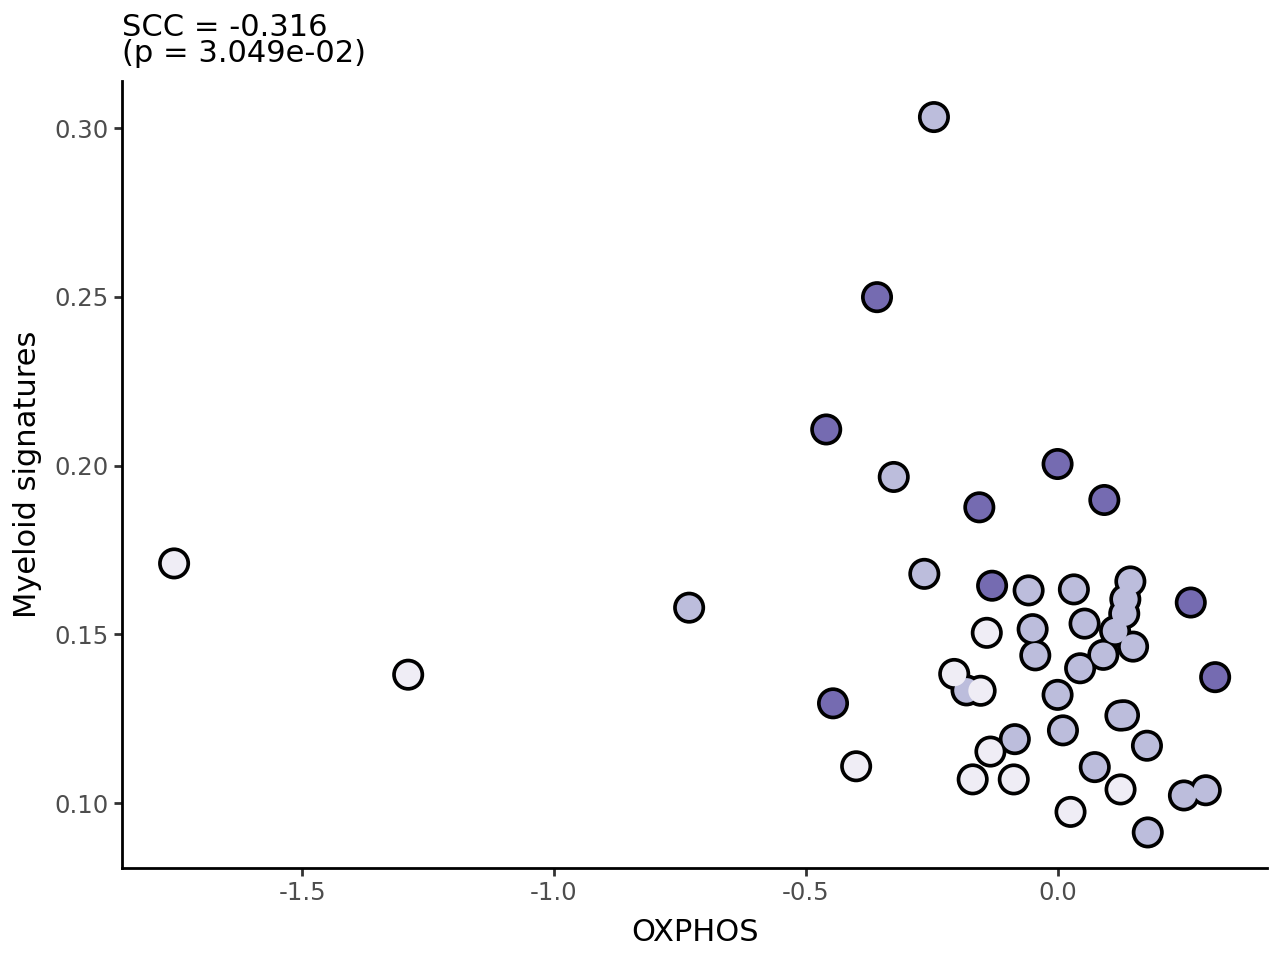


OXIDATIVE_PHOSPHORYLATION vs Mye_tot:
  Overall correlation: -0.316
  G2: -0.510
  G1: -0.718
  G3: -0.367


/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 3.5 x 4 in image.
/home/loan/miniforge3/envs/liana/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ../../figures/fig6/heiser_oxidativephosphorylation_vs_epitot_by_grade.pdf


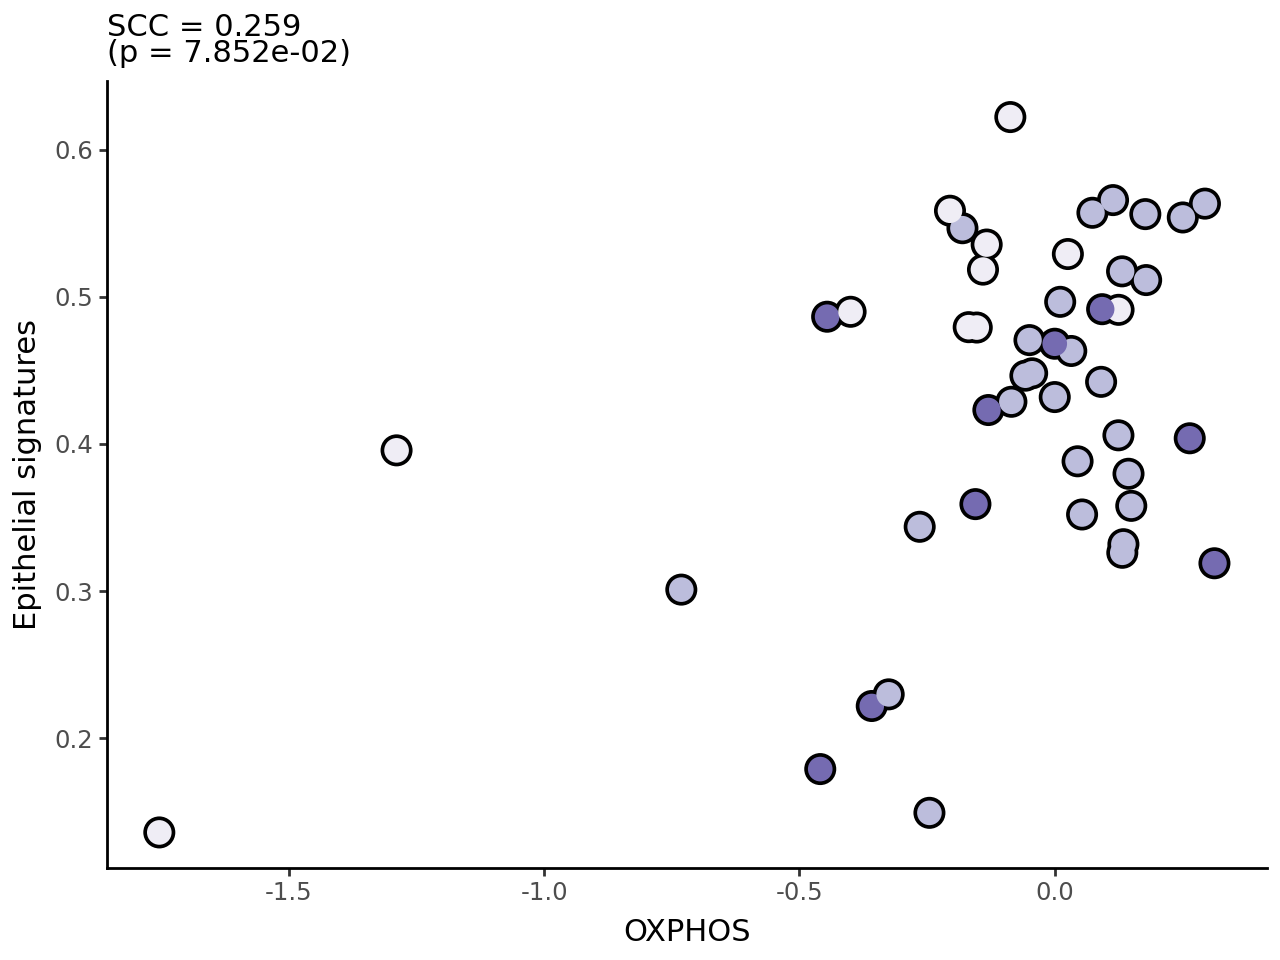


OXIDATIVE_PHOSPHORYLATION vs Epi_tot:
  Overall correlation: 0.259
  G2: 0.416
  G1: 0.618
  G3: 0.267


In [19]:
# 5) Create pairwise scatterplots stratified by Tumor Grade
print("Creating pairwise scatterplots stratified by Tumor Grade...")

# Compare each to OxPhos
plot_pairs = [('OXIDATIVE_PHOSPHORYLATION', 'Mye_tot'),
              ('OXIDATIVE_PHOSPHORYLATION', 'Epi_tot')]

for col1, col2 in plot_pairs:
    # Calculate overall correlation
    overall_correlation = merged_data[col1].corr(merged_data[col2], method='spearman')
    # Calculate correlation and p-value
    overall_correlation, p_value = spearmanr(merged_data[col1], 
                                             merged_data[col2])

    # Calculate correlation per grade
    grade_correlations = {}
    for grade in merged_data['Tumor_Grade'].unique():
        grade_data = merged_data[merged_data['Tumor_Grade'] == grade]
        corr = grade_data[col1].corr(grade_data[col2], method='spearman')
        grade_correlations[grade] = corr
    
    # Create human-friendly labels
    label_dict = {
        'OXIDATIVE_PHOSPHORYLATION': 'OXPHOS',
        'FATTY_ACID_METABOLISM': 'Fatty acid metabolism', 
        'GLYCOLYSIS': 'Glycolysis',
        'Mye_tot': 'Myeloid signatures',
        'Epi_tot': 'Epithelial signatures'
    }
    
    # Get human-friendly labels
    col1_label = label_dict.get(col1, col1.replace('_', ' ').title())
    col2_label = label_dict.get(col2, col2.replace('_', ' ').title())
    
    # Create plot stratified by Tumor Grade
    g = (ggplot(merged_data, aes(x=col1, 
                                 color='Tumor_Grade',
                                 y=col2)) +
         geom_point(aes(x=col1, y=col2), size=5.5, color="black") +
         geom_point(size=4) +
         labs(subtitle=f'SCC = {overall_correlation:.3f}\n(p = {p_value:.3e})',
              x=col1_label,
              y=col2_label) +
         scale_color_brewer(palette="Purples") +
         guides(color="none") +
         theme_classic()
    )
    
    safe_name1 = col1.replace('_', '').replace(' ', '').lower()
    safe_name2 = col2.replace('_', '').replace(' ', '').lower()
    
    ggsave(g, filename=f"../../figures/fig6/heiser_{safe_name1}_vs_{safe_name2}_by_grade.pdf",
           width=3.5, height=4)

    g.show()
    
    # Print grade-specific correlations
    print(f"\n{col1} vs {col2}:")
    print(f"  Overall correlation: {overall_correlation:.3f}")
    for grade, corr in grade_correlations.items():
        if not np.isnan(corr):
            print(f"  {grade}: {corr:.3f}")
        else:
            print(f"  {grade}: insufficient data")

## Multicellularity

In [20]:
# split refNMF cell states by compartment (as in original paper)
# https://github.com/Ken-Lau-Lab/spatial_CRC_atlas/blob/64e585453514801a3b730f86aec90bbc0f0595da/step5/ST_summaries.ipynb#L776
nmf_epi = [
 'STM',
 'CRC1',
 'CRC2',
 'CT',
 'SSC',
 'CRC3',
 'EE1',
 'GOB',
 'CRC4',
 'ABS',
 'TUF',
 'EE2',
]
nmf_epi.sort()

nmf_stroma = [
 'END1',
 'FIB1',
 'FIB2',
 'FIB3',
 'FIB4',
 'END2',
]
nmf_stroma.sort()

nmf_immune = [
 'BL1',
 'MYE1',
 'TL1',
 'MYE2',
 'MYE3',
 'PLA',
 'MYE4',
 'MAS',
 'MYE5',
 'TL2',
 'TL3',
 'BL2'
]

assert np.all([x in a_comb.obs.columns for x in nmf_epi + nmf_stroma + nmf_immune]), "Not all features found in obs"

In [21]:
# Prepare data for all experiments
a_graded = a_comb.obs[a_comb.obs['Tumor Grade'].isin(['G1', 'G2', 'G3'])].copy()
a_graded['Tumor Grade'] = a_graded['Tumor Grade'].cat.remove_unused_categories()
a_graded['Sample'] = a_graded['Sample'].cat.remove_unused_categories()
a_graded['Patient'] = a_graded['Patient'].cat.remove_unused_categories()

# Define feature groups
epi_ft = nmf_epi
stromal_ft = nmf_stroma + nmf_immune
all_ft = epi_ft + stromal_ft

In [22]:
# Prepare different feature sets by aggregating per sample/patient/grade
print(f"\nAggregating features by Sample, Patient, and Tumor Grade...")

# Epithelial features
epi_df = a_graded.groupby(['Sample', 'Tumor Grade', 'Patient'], observed=True)[epi_ft].mean().join(
         a_graded.groupby(['Sample', 'Tumor Grade', 'Patient'], observed=True)[epi_ft].std(), rsuffix="_std")

# Stromal features
stromal_df = a_graded.groupby(['Sample', 'Tumor Grade', 'Patient'], observed=True)[stromal_ft].mean().join(
             a_graded.groupby(['Sample', 'Tumor Grade', 'Patient'], observed=True)[stromal_ft].std(), rsuffix="_std")

# Combined features (all compartments)
combined_df = a_graded.groupby(['Sample', 'Tumor Grade', 'Patient'], observed=True)[all_ft].mean().join(
              a_graded.groupby(['Sample', 'Tumor Grade', 'Patient'], observed=True)[all_ft].std(), rsuffix="_std")

# Prepare metadata
meta = a_graded.groupby(['Sample', 'Tumor Grade', 'Patient'], observed=True)[['Tumor Type']].first()
meta.reset_index(inplace=True)

print(f"\nData shapes:")
print(f"  Epithelial: {epi_df.shape}")
print(f"  TME: {stromal_df.shape}")
print(f"  Combined: {combined_df.shape}")
print(f"  Number of unique patients: {meta['Patient'].nunique()}")


Aggregating features by Sample, Patient, and Tumor Grade...

Data shapes:
  Epithelial: (47, 24)
  TME: (47, 36)
  Combined: (47, 60)
  Number of unique patients: 29


In [ ]:
def perform_lopo_classification(df, meta, experiment_name, shuffle_labels=False):
    """
    Perform Leave One Patient Out cross-validation classification
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Feature matrix (one row per sample)
    meta : pandas.DataFrame
        Metadata with Patient and Tumor Grade (one row per sample)
    experiment_name : str
        Name of the experiment
    shuffle_labels : bool
        Whether to shuffle the tumor grade labels
    
    Returns:
    --------
    tuple : (sample_level_macro_f1, patient_accuracies_list)
    """
    print(f"\n=== {experiment_name} ===")
    
    # Reset indices to ensure alignment
    df = df.reset_index(drop=True)
    meta_local = meta.reset_index(drop=True)
    
    # Shuffle labels if requested
    if shuffle_labels:
        meta_local = meta_local.copy()
        meta_local['Tumor Grade'] = np.random.permutation(meta_local['Tumor Grade'].values)
        print("Labels shuffled for null model")
    
    # Initialize Leave One Patient Out cross-validator
    cv_folds = LeaveOneGroupOut()
    
    # Collect all sample-level predictions
    all_y_true = []
    all_y_pred = []
    
    # Collect per-patient results
    patient_results = []
    
    for train_idx, test_idx in tqdm(cv_folds.split(df.values, 
                                              meta_local["Tumor Grade"], 
                                              groups=meta_local["Patient"]), 
                                   desc=f"LOPO {experiment_name}"):
        
        # Get patient being left out
        test_patient = meta_local["Patient"].iloc[test_idx[0]]
        
        # Check if all grades are present in training set
        train_grades = set(meta_local["Tumor Grade"].iloc[train_idx].unique())
        test_grades = set(meta_local["Tumor Grade"].iloc[test_idx].unique())
        
        # Skip if not all grades are present in training set
        if len(train_grades) < 3:
            print(f"Skipping patient {test_patient} - only {len(train_grades)} grades in training set")
            continue
        
        # Train classifier
        classifier = XGBClassifier(
            n_estimators=20, 
            max_depth=5, 
            device="cuda", 
            random_state=0
        )
        
        # Fit on training data
        X_train, X_test = df.values[train_idx], df.values[test_idx]
        
        # Create consistent label encoder
        le = LabelEncoder()
        le.fit(meta_local["Tumor Grade"].iloc[train_idx])
        
        y_train = le.transform(meta_local["Tumor Grade"].iloc[train_idx])
        y_test_labels = meta_local["Tumor Grade"].iloc[test_idx]
        
        # Only include test samples with grades seen in training
        valid_test_mask = y_test_labels.isin(le.classes_)
        if not valid_test_mask.any():
            print(f"Skipping patient {test_patient} - no valid test grades")
            continue
            
        # Filter test data to only valid samples
        valid_test_idx = test_idx[valid_test_mask]
        X_test_valid = df.values[valid_test_idx]
        y_test_valid_labels = meta_local["Tumor Grade"].iloc[valid_test_idx]
        y_test_valid = le.transform(y_test_valid_labels)
        
        classifier.fit(X_train, y_train)
        
        # Predict on test data
        y_pred = classifier.predict(X_test_valid)
        
        # Store sample-level predictions for overall macro-F1
        all_y_true.extend(y_test_valid)
        all_y_pred.extend(y_pred)
        
        # Calculate per-patient accuracy
        patient_accuracy = (y_test_valid == y_pred).mean()
        
        patient_results.append({
            'Patient': test_patient,
            'Accuracy': patient_accuracy,
            'n_samples': len(y_test_valid),
            'test_grades': list(y_test_valid_labels.unique())
        })
            
    # Calculate overall sample-level macro-F1
    if len(all_y_true) > 0:
        sample_macro_f1 = f1_score(all_y_true, all_y_pred, average='macro')
    else:
        sample_macro_f1 = float('nan')
    
    # Extract patient accuracies if several samples are present
    patient_accuracies = [result['Accuracy'] for result in patient_results
                          if result['n_samples'] > 1]
    
    print(f"Sample-level Macro F1 Score: {sample_macro_f1:.3f}")
    print(f"Mean Patient Accuracy: {np.mean(patient_accuracies):.3f} ± {np.std(patient_accuracies):.3f}")
    print(f"Number of valid patients: {len(patient_accuracies)}")
    print(f"Total samples: {len(all_y_true)}")
    
    return sample_macro_f1, patient_accuracies


In [ ]:
def perform_multiple_shuffle_experiments(df, meta, experiment_name, n_shuffles=10):
    """
    Perform multiple shuffle experiments to build null distribution
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Feature matrix
    meta : pandas.DataFrame
        Metadata with Patient and Tumor Grade
    experiment_name : str
        Name of the experiment
    n_shuffles : int
        Number of shuffle experiments to perform
    
    Returns:
    --------
    tuple : (real_f1, real_accuracies, shuffle_f1s, shuffle_accuracies_list)
    """
    print(f"\n=== {experiment_name} - Multiple Shuffles ===")
    
    # Perform real experiment
    real_f1, real_accuracies = perform_lopo_classification(df, meta, f"{experiment_name} (Real)", shuffle_labels=False)
    
    # Perform multiple shuffle experiments
    shuffle_f1s = []
    all_shuffle_accuracies = []
    
    for i in range(n_shuffles):
        print(f"Shuffle {i+1}/{n_shuffles}")
        shuffle_f1, shuffle_accuracies = perform_lopo_classification(df, meta, f"{experiment_name} (Shuffle {i+1})", shuffle_labels=True)
        shuffle_f1s.append(shuffle_f1)
        all_shuffle_accuracies.extend(shuffle_accuracies)
    
    # Summary statistics
    print(f"\n{experiment_name} Summary:")
    print(f"Real F1: {real_f1:.3f}")
    print(f"Shuffle F1s: {np.mean(shuffle_f1s):.3f} ± {np.std(shuffle_f1s):.3f}")
    print(f"Real Patient Accuracy: {np.mean(real_accuracies):.3f} ± {np.std(real_accuracies):.3f}")
    print(f"Shuffle Patient Accuracy: {np.mean(all_shuffle_accuracies):.3f} ± {np.std(all_shuffle_accuracies):.3f}")
    
    return real_f1, real_accuracies, shuffle_f1s, all_shuffle_accuracies


In [ ]:
# Perform experiments with multiple shuffles for all 3 feature sets
print("Performing experiments with multiple shuffles...")

# Set random seed for reproducibility
np.random.seed(0)

# Number of shuffle experiments per feature set
n_shuffles = 100

# 1. Epithelial features
epi_real_f1, epi_real_acc, epi_shuffle_f1s, epi_shuffle_accs = perform_multiple_shuffle_experiments(
    epi_df, meta, "Epithelial Signatures", n_shuffles=n_shuffles)

# 2. Stromal features
stromal_real_f1, stromal_real_acc, stromal_shuffle_f1s, stromal_shuffle_accs = perform_multiple_shuffle_experiments(
    stromal_df, meta, "Stromal Signatures", n_shuffles=n_shuffles)

# 3. Combined features
combined_real_f1, combined_real_acc, combined_shuffle_f1s, combined_shuffle_accs = perform_multiple_shuffle_experiments(
    combined_df, meta, "Combined Signatures", n_shuffles=n_shuffles)

# Compile results for plotting
all_results = []

# Add real results
for acc in epi_real_acc:
    all_results.append({'Features': 'Epithelial', 'Accuracy': acc, 'Type': 'Real'})
for acc in stromal_real_acc:
    all_results.append({'Features': 'Stromal', 'Accuracy': acc, 'Type': 'Real'})
for acc in combined_real_acc:
    all_results.append({'Features': 'Combined', 'Accuracy': acc, 'Type': 'Real'})

# Add shuffle results (pooled across all shuffle experiments)
for acc in epi_shuffle_accs:
    all_results.append({'Features': 'Epithelial', 'Accuracy': acc, 'Type': 'Shuffled'})
for acc in stromal_shuffle_accs:
    all_results.append({'Features': 'Stromal', 'Accuracy': acc, 'Type': 'Shuffled'})
for acc in combined_shuffle_accs:
    all_results.append({'Features': 'Combined', 'Accuracy': acc, 'Type': 'Shuffled'})

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

In [ ]:
# Reverse the order of feature sets
feature_sets_reversed = ['Stromal', 'Epithelial', 'Combined']

# Calculate mean accuracies and F1 scores for labels
mean_stats = []
p_values_for_fdr = []

for feature_set in feature_sets_reversed:
    real_data = results_df[(results_df['Features'] == feature_set) & (results_df['Type'] == 'Real')]['Accuracy']
    shuffle_data = results_df[(results_df['Features'] == feature_set) & (results_df['Type'] == 'Shuffled')]['Accuracy']
    
    # Get F1 scores from the original results
    if feature_set == 'Epithelial':
        real_f1, shuffle_f1s = epi_real_f1, epi_shuffle_f1s
    elif feature_set == 'Stromal':
        real_f1, shuffle_f1s = stromal_real_f1, stromal_shuffle_f1s
    elif feature_set == 'Combined':
        real_f1, shuffle_f1s = combined_real_f1, combined_shuffle_f1s
    
    # Calculate p-value
    if len(real_data) > 0 and len(shuffle_data) > 0:
        stat, p_val = mannwhitneyu(real_data, shuffle_data, alternative='greater')
        p_values_for_fdr.append(p_val)
    else:
        p_values_for_fdr.append(1.0)  # Non-significant default
    
    # Store statistics for labels (will update p-values after FDR correction)
    mean_stats.extend([
        {'Features': feature_set, 'Type': 'Real', 'Mean': real_data.mean(), 'F1': f"{real_f1:.3f}", 'P_value_raw': p_val if len(real_data) > 0 and len(shuffle_data) > 0 else 1.0},
        {'Features': feature_set, 'Type': 'Shuffled', 'Mean': shuffle_data.mean(), 'F1': f"{np.mean(shuffle_f1s):.3f}", 'P_value_raw': ""}
    ])

# Apply FDR correction
rejected, fdr_corrected_p_values, alpha_sidak, alpha_bonf = multipletests(p_values_for_fdr, method='fdr_bh')

# Update mean_stats with FDR-corrected p-values
fdr_idx = 0
for i in range(len(mean_stats)):
    if mean_stats[i]['Type'] == 'Real':
        fdr_p = fdr_corrected_p_values[fdr_idx]
        if fdr_p < 0.001:
            p_text = "FDR<0.001"
        elif fdr_p < 0.01:
            p_text = f"FDR={fdr_p:.3f}"
        elif fdr_p < 0.05:
            p_text = f"FDR={fdr_p:.2f}"
        else:
            p_text = f"FDR={fdr_p:.2f}"
        mean_stats[i]['P_value'] = p_text
        fdr_idx += 1
    else:
        mean_stats[i]['P_value'] = ""

# Convert to DataFrame for easier handling
stats_df = pd.DataFrame(mean_stats)

# Reverse the order of features in the results dataframe
results_df['Features'] = pd.Categorical(results_df['Features'], 
                                       categories=feature_sets_reversed, 
                                       ordered=True)

# Create the plot
g = (ggplot(results_df, aes(x='Features', y='Accuracy', fill='Type')) +
     geom_boxplot(outlier_shape=None, alpha=0.7, position='dodge') +
     stat_summary(fun_y=np.mean, geom='point', color='white', size=3, 
                  position=position_dodge(width=0.75)) +
     geom_jitter(aes(color='Type'), alpha=0.5, size=1.5, 
                position=position_jitterdodge(dodge_width=0.75, jitter_width=0.15)) +
     scale_fill_manual(values=['#9E9AC8', '#acabab'], 
                       labels=['Real Labels', 'Shuffled Labels']) +
     scale_color_manual(values=['#9E9AC8', '#acabab'], 
                        labels=['Real Labels', 'Shuffled Labels']) +
     labs(
          x='Feature Set',
          y='Per-Patient Accuracy',
          fill='Label Type',
          color='Label Type') +
     theme_classic() +
     theme(legend_position='bottom'))

# Calculate label positions more systematically
label_data = []

for i, feature_set in enumerate(feature_sets_reversed):
    # Get max y value for positioning labels
    feature_data = results_df[results_df['Features'] == feature_set]['Accuracy']
    max_y = feature_data.max()
    
    # Real condition F1 label (left side of pair)
    real_f1 = stats_df[(stats_df['Features'] == feature_set) & (stats_df['Type'] == 'Real')]['F1'].iloc[0]
    label_data.append({
        'x_pos': 1 + i - 0.2,  # Offset left for Real condition 
        'y_pos': max_y + 0.1,
        'label': f"F1: {real_f1}",
        'size': 8
    })
    
    # Shuffled condition F1 label (right side of pair)
    shuffle_f1 = stats_df[(stats_df['Features'] == feature_set) & (stats_df['Type'] == 'Shuffled')]['F1'].iloc[0]
    label_data.append({
        'x_pos': 1 + i + 0.2,  # Offset right for Shuffled condition
        'y_pos': max_y + 0.1,
        'label': f"F1: {shuffle_f1}",
        'size': 8
    })
    
    # FDR-corrected p-value label centered above both boxes
    p_value = stats_df[(stats_df['Features'] == feature_set) & (stats_df['Type'] == 'Real')]['P_value'].iloc[0]
    label_data.append({
        'x_pos': 1 + i,  # Centered between the pair
        'y_pos': max_y + 0.03,
        'label': p_value,
        'size': 8
    })

# Convert label data to DataFrame
label_df = pd.DataFrame(label_data)

# Add text annotations with proper positioning
for _, row in label_df.iterrows():
    g = g + annotate("text", x=row['x_pos'], y=row['y_pos'], 
                     label=row['label'], size=row['size'], ha='center', va='bottom')

# Adjust y-axis limits to accommodate labels
y_range = results_df['Accuracy'].max() - results_df['Accuracy'].min()
g = g +\
    ylim(results_df['Accuracy'].min() - 0.05 * y_range, 
             results_df['Accuracy'].max() + 0.15 * y_range) +\
    scale_y_continuous(breaks=[0, 0.2, 0.4, 0.6, 0.8, 1.0])


ggsave(g, filename="../../figures/fig6/heiser_lopo_four_compartments.pdf",
       width=5, height=4, dpi=300)

g.show()

# Print FDR correction summary
print(f"\n=== FDR CORRECTION SUMMARY ===")
for i, feature_set in enumerate(feature_sets_reversed):
    raw_p = p_values_for_fdr[i]
    fdr_p = fdr_corrected_p_values[i]
    is_significant = rejected[i]
    print(f"{feature_set}: Raw p={raw_p:.4f}, FDR p={fdr_p:.4f}, Significant: {is_significant}")
